In [63]:
# Description
# Capstone Project: Student Success & Career Path Prediction

# Scenario

# The university wants to analyze student performance data to:

# Predict exam scores (Regression).
# Classify students into “At Risk” vs. “On Track” categories (Classification).
# Cluster students into groups with similar study habits (Clustering).
# Recommend interventions (extra tutoring, workshops, counseling).
# /content/Student Success & Career Path  - Sheet1.csv


In [64]:
#1. Regression: Predict Final Exam Score
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [65]:
# Load dataset
df = pd.DataFrame({
    'Student_ID':               ['S001','S002','S003','S004','S005','S006','S007','S008','S009','S010',
                                    'S011','S012','S013','S014','S015','S016','S017','S018','S019','S020'],
    'Hours_Studied':            [10,5,12,3,8,6,2,11,4,9,7,1,13,6,4,10,5,12,3,9],
    'Attendance (%)':           [85,60,90,40,75,65,30,88,50,80,72,25,92,60,45,87,55,91,35,82],
    'Assignments_Submitted':    [8,5,9,3,7,6,2,9,4,8,6,1,10,5,3,8,4,9,2,8],
    'Previous_Sem_GPA':         [3.2,2.5,3.8,2.0,3.0,2.7,1.8,3.5,2.2,3.1,2.9,1.5,3.9,2.6,2.1,3.4,2.3,3.7,1.9,3.2],
    'Participation_Score':      [70,55,80,45,65,60,40,75,50,68,63,35,85,58,48,72,52,78,42,70],
    'Final_Exam_Score':         [78,55,88,45,70,60,40,82,50,75,68,35,90,58,48,80,52,85,42,77],
    'Pass_Fail':                ['Pass','Fail','Pass','Fail','Pass','Pass','Fail','Pass','Fail','Pass',
                                    'Pass','Fail','Pass','Pass','Fail','Pass','Fail','Pass','Fail','Pass'],
    'Career_Readiness_Score':   [65,40,75,35,60,55,25,70,45,62,58,20,80,50,38,68,42,72,30,64],
    'Age':                      [20,21,22,19,23,20,21,22,19,20,21,19,22,20,21,23,19,22,20,21],
    'Gender':                   ['Female','Male','Female','Male','Female','Male','Female','Male','Female','Male',
                                    'Female','Male','Female','Male','Female','Male','Female','Male','Female','Male']
})

In [66]:
df.isnull().sum()

Student_ID                0
Hours_Studied             0
Attendance (%)            0
Assignments_Submitted     0
Previous_Sem_GPA          0
Participation_Score       0
Final_Exam_Score          0
Pass_Fail                 0
Career_Readiness_Score    0
Age                       0
Gender                    0
dtype: int64

In [67]:
# Select features and target
X = df[["Hours_Studied", "Attendance (%)", "Assignments_Submitted","Previous_Sem_GPA", "Participation_Score", "Age"]]
y = df["Final_Exam_Score"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

MAE: 1.4608469164982356
R2 Score: 0.9777856656078586


In [68]:
# Classification of At Risk vs On Track
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Encode target
df["Pass_Fail"] = df["Pass_Fail"].map({"Pass": 1, "Fail": 0})

X = df[["Hours_Studied", "Attendance (%)", "Assignments_Submitted","Previous_Sem_GPA", "Participation_Score"]]
y = df["Pass_Fail"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [69]:
# Model Fitting
clf = LogisticRegression()
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.75      1.00      0.86         3

    accuracy                           0.75         4
   macro avg       0.38      0.50      0.43         4
weighted avg       0.56      0.75      0.64         4



C:\Users\sk165\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sk165\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sk165\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas

In [70]:
#3 Clustering of Study Habit Groups

features = df[["Hours_Studied", "Attendance (%)", "Assignments_Submitted","Previous_Sem_GPA", "Participation_Score"]]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
wcss = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    df["Cluster"] = kmeans.fit_predict(scaled_features)
    wcss.append(kmeans.inertia_)
df[["Student_ID", "Hours_Studied","Attendance (%)", "Participation_Score", "Cluster"]].head()

,Student_ID,Hours_Studied,Attendance (%),Participation_Score,Cluster
0,S001,10,85,70,3
1,S002,5,60,55,6
2,S003,12,90,80,8
3,S004,3,40,45,1
4,S005,8,75,65,2


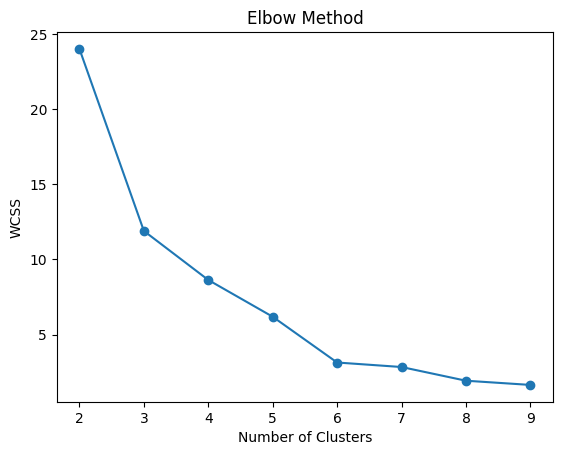

In [71]:
plt.plot(range(2,10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
# Fitting model on best parameter
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled_features)

In [72]:
#4 Intervention Recommendation Logic
def recommend(row):
    if row["Pass_Fail"] == 0:
        return "MandatoryTutoring + Counseling"
    elif row["Hours_Studied"] < 5:
        return "StudentSkillsWorkshop"
    elif row["Attendance (%)"] < 60:
        return "Attendance Monitoring Program"
    else:
        return "On Track"

df["Recommendation"] = df.apply(recommend, axis=1)

df[["Student_ID", "Recommendation"]]

,Student_ID,Recommendation
0,S001,On Track
1,S002,MandatoryTutoring + Counseling
2,S003,On Track
3,S004,MandatoryTutoring + Counseling
4,S005,On Track
5,S006,On Track
6,S007,MandatoryTutoring + Counseling
7,S008,On Track
8,S009,MandatoryTutoring + Counseling
9,S010,On Track
